<a href="https://colab.research.google.com/github/BelLobo/Data-Science-CODERHOUSE/blob/main/ProyectoFinalDSIII_Lobo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Dataset: Women's E-Commerce Clothing Reviews
##Descripción general
Este dataset contiene reseñas reales de clientes de un e-commerce de ropa femenina. Cada fila representa una review realizada por una clienta e incluye tanto información textual como variables estructuradas relacionadas con el producto y la interacción del usuario.
##Objetivo del proyecto
El objetivo de este proyecto es construir un pipeline de Procesamiento de Lenguaje Natural (NLP) para analizar automáticamente el feedback de clientes en un contexto de e-commerce.
Se implementaron técnicas de preprocesamiento de texto, vectorización (TF-IDF), clasificación supervisada (Regresión Logística y Red Neuronal con PyTorch) y modelado de tópicos no supervisado (LDA).

## Variables del dataset
### Columna	| Descripción
Clothing ID	| Identificador único de la prenda

Age	| Edad de la clienta

Title	| Título breve de la review

Review | Text	Texto principal de la review

Rating	| Puntuación otorgada al producto (1 a 5)

Recommended IND	| Indica si la clienta recomienda el producto (1 = sí, 0 = no)

Positive Feedback Count	| Cantidad de usuarios que encontraron útil la review

Division Name	| División general del producto

Department Name	| Departamento del producto

Class Name	| Categoría específica del producto


## Variable generada
### Columna	| Descripción
full_text	| Concatenación de Title y Review Text para enriquecer el contexto textual utilizado en el análisis NLP

## Consideraciones iniciales

Se eliminaron filas con valores faltantes en variables críticas (Title, Review Text, Division Name, Department Name, Class Name) para garantizar consistencia en el análisis. El análisis se enfoca principalmente en la columna full_text. La variable objetivo utilizada para clasificación es Recommended IND.


## 1. EDA (Exploratory Data Analysis)

### 1.1 Carga del dataset y limpieza inicial

In [ ]:
# Cargar el dataset desde KaggleHub y realizar una primera inspección:

import kagglehub
import pandas as pd
import os

# Descargar la última versión del dataset
path = kagglehub.dataset_download("nicapotato/womens-ecommerce-clothing-reviews")

print("Path to dataset files:", path)

# Listar archivos en el path descargado
print(os.listdir(path))

# Cargar el dataset en un DataFrame
df = pd.read_csv(os.path.join(path, "Womens Clothing E-Commerce Reviews.csv"))

# Mostrar las primeras filas del DataFrame
display(df.head())

Using Colab cache for faster access to the 'womens-ecommerce-clothing-reviews' dataset.
Path to dataset files: /kaggle/input/womens-ecommerce-clothing-reviews
['Womens Clothing E-Commerce Reviews.csv']


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


Información general y conteo de valores nulos para entender la calidad de los datos:

In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


,0
Unnamed: 0,0
Clothing ID,0
Age,0
Title,3810
Review Text,845
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,14
Department Name,14


Eliminamos la columna `Unnamed: 0` que es un índice redundante y las filas con valores faltantes en columnas críticas (`Title`, `Review Text`, `Division Name`, `Department Name`, `Class Name`) para asegurar la consistencia del análisis:

In [ ]:
df = df.drop(columns=["Unnamed: 0"])
df = df.dropna(
    subset=[
        "Title",
        "Review Text",
        "Division Name",
        "Department Name",
        "Class Name"
    ]
)

print(f"Dimensiones del DataFrame después de la limpieza: {df.shape}")
display(df.head())

Dimensiones del DataFrame después de la limpieza: (19662, 10)


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
5,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",2,0,4,General,Dresses,Dresses
6,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,5,1,1,General Petite,Tops,Knits


Creamos la columna `full_text` concatenando `Title` y `Review Text` para el procesamiento NLP.

In [ ]:
df["full_text"] = df["Title"] + ". " + df["Review Text"]
display(df.head())

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,full_text
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,Some major design flaws. I had such high hopes...
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,"My favorite buy!. I love, love, love this jump..."
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,Flattering shirt. This shirt is very flatterin...
5,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",2,0,4,General,Dresses,Dresses,Not for the very petite. I love tracy reese dr...
6,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,5,1,1,General Petite,Tops,Knits,Cagrcoal shimmer fun. I aded this in my basket...


### 1.2 Distribución de Ratings y Recomendación

Analizamos la distribución de las puntuaciones (`Rating`) y la variable objetivo (`Recommended IND`), que indica si el cliente recomienda el producto.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Distribución de Ratings:")
display(df["Rating"].value_counts().sort_index())
display(df["Rating"].value_counts(normalize=True).sort_index())

print("\nDistribución de Recommended IND:")
display(df["Recommended IND"].value_counts())
display(df["Recommended IND"].value_counts(normalize=True))

print("\nCruce de Ratings y Recommended IND:")
display(pd.crosstab(df["Rating"], df["Recommended IND"]))

Distribución de Ratings:


,count
Rating,
1,691
2,1360
3,2464
4,4289
5,10858


,proportion
Rating,
1,0.035144
2,0.069169
3,0.125318
4,0.218137
5,0.552233



Distribución de Recommended IND:


,count
Recommended IND,
1,16087
0,3575


,proportion
Recommended IND,
1,0.818177
0,0.181823



Cruce de Ratings y Recommended IND:


Recommended IND,0,1
Rating,,
1,684,7
2,1280,80
3,1444,1020
4,146,4143
5,21,10837


Visualización de la distribución de Ratings para reviews recomendadas y no recomendadas.

/tmp/ipykernel_9981/3604316189.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_9981/3604316189.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


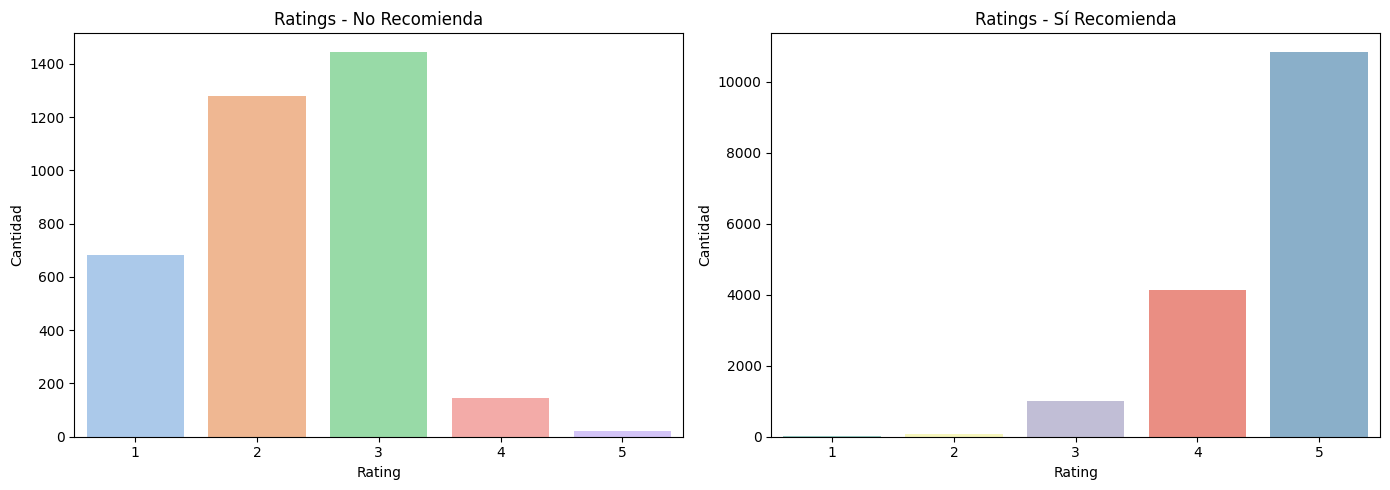

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# No recomienda
sns.countplot(
    data=df[df["Recommended IND"] == 0],
    x="Rating",
    palette="pastel",
    ax=axes[0]
)

axes[0].set_title("Ratings - No Recomienda")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Cantidad")

# Sí recomienda
sns.countplot(
    data=df[df["Recommended IND"] == 1],
    x="Rating",
    palette="Set3",
    ax=axes[1]
)

axes[1].set_title("Ratings - Sí Recomienda")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Cantidad")

plt.tight_layout()
plt.show()

### 1.3 Distribución de Edades

Exploramos la distribución de la edad de las clientas y creamos grupos etarios para una mejor visualización.

Estadísticas descriptivas de la edad:


,Age
count,19662.000000
mean,43.260808
std,12.258122
min,18.000000
25%,34.000000
50%,41.000000
75%,52.000000
max,99.000000


/tmp/ipykernel_9981/3093056951.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


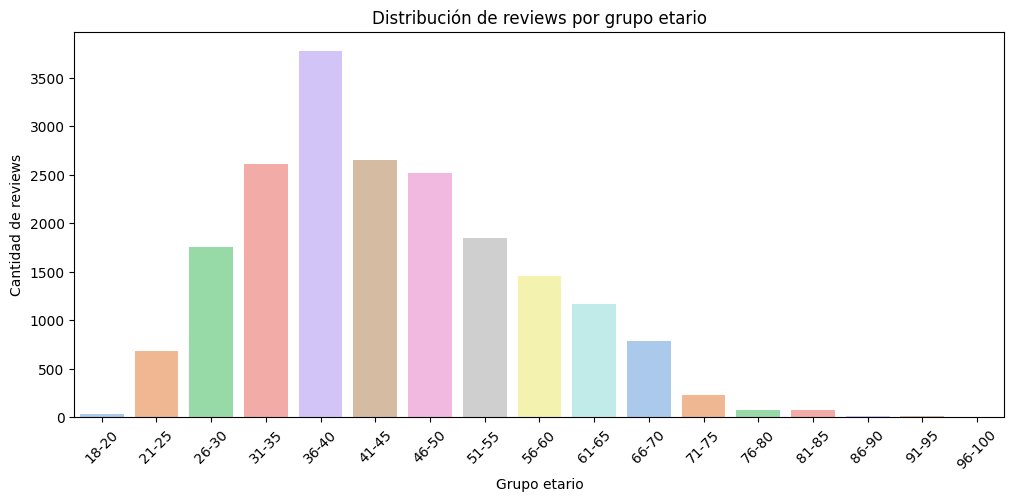

In [ ]:
print("Estadísticas descriptivas de la edad:")
display(df["Age"].describe())

bins = [18, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
labels = [
    "18-20", "21-25", "26-30", "31-35",
    "36-40", "41-45", "46-50", "51-55",
    "56-60", "61-65", "66-70", "71-75",
    "76-80", "81-85", "86-90", "91-95", "96-100"
]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels, right=False # include 18, exclude 20
)

plt.figure(figsize=(12,5))
sns.countplot(
    data=df,
    x="Age Group",
    palette="pastel"
)

plt.title("Distribución de reviews por grupo etario")
plt.xlabel("Grupo etario")
plt.ylabel("Cantidad de reviews")
plt.xticks(rotation=45)
plt.show()

### 1.4 Análisis de Clase de Producto

Analizamos la distribución de las `Class Name` para identificar las categorías de productos más frecuentes.

Conteo de Class Name:


,count
Class Name,
Dresses,5371
Knits,3981
Blouses,2587
Sweaters,1218
Pants,1157
Jeans,970
Fine gauge,927
Skirts,796
Jackets,598


/tmp/ipykernel_9981/2702338579.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


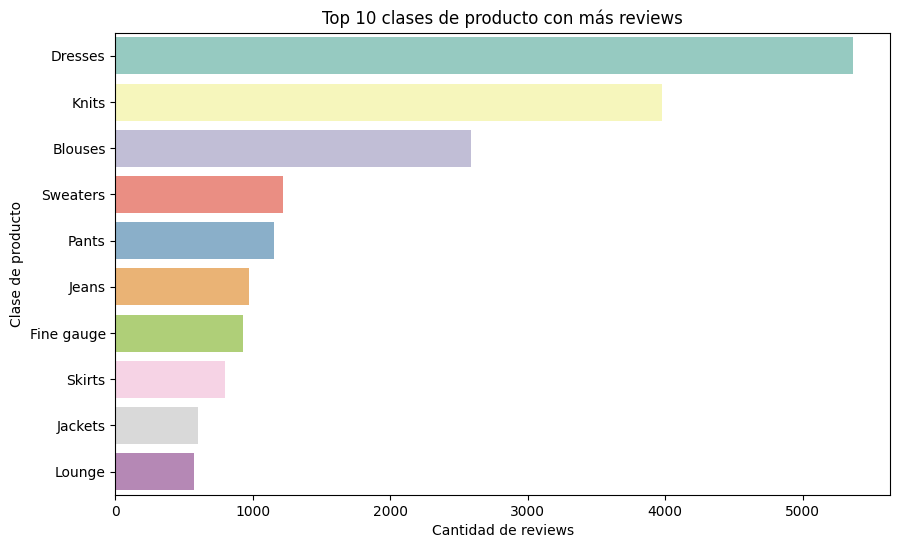

In [ ]:
print("Conteo de Class Name:")
display(df["Class Name"].value_counts())

top_classes = df["Class Name"].value_counts().head(10).index

plt.figure(figsize=(10,6))
sns.countplot(
    data=df[df["Class Name"].isin(top_classes)],
    y="Class Name",
    order=top_classes,
    palette="Set3"
)

plt.title("Top 10 clases de producto con más reviews")
plt.xlabel("Cantidad de reviews")
plt.ylabel("Clase de producto")
plt.show()

### 1.5 Longitud de Reviews y Ejemplos

Calculamos la longitud de las reviews y mostramos ejemplos de reseñas positivas y negativas para una primera impresión.

In [ ]:
df["review_length"] = df["full_text"].apply(len)
print("Estadísticas descriptivas de la longitud de las reviews:")
display(df["review_length"].describe())

print("\nEjemplos de reviews con Rating 1 (negativas):")
display(df[df["Rating"] == 1]["full_text"].sample(3).tolist())

print("\nEjemplos de reviews con Rating 5 (positivas):")
display(df[df["Rating"] == 5]["full_text"].sample(3).tolist())

Estadísticas descriptivas de la longitud de las reviews:


,review_length
count,19662.000000
mean,339.543739
std,144.724645
min,24.000000
25%,218.000000
50%,337.000000
75%,497.000000
max,558.000000



Ejemplos de reviews con Rating 1 (negativas):


['Chevron pattern off center in back. I purchased this swimsuit in the mint. gorgeous color combination. i\'m 5\'5" and weigh 117 lbs. i purchased a small. the fit is true to size. i love the front design; however, my husband promptly brought the back of the swimsuit to my attention. the chevron was off center. the design should have been centered with my back; however, it was on the right side of my back. i immediately called retailer assuming the product was defective. the item was sold out on line; however, a supervisor was able to l',
 'Poor fit. The fit of this sweater did not flatter my body-type. the top half did not fit well; the armpit area was loose fitting and the neckline was awkward.',
 "Disappointed. The top looks better on the model than in-person. it fits loose and looks boxy and matronly. i don't like the sleeve length or the top style, it just didn't look flattering or good. i am sending it back. looks very boxy."]


Ejemplos de reviews con Rating 5 (positivas):


['In love!!. I think this dress is my favorite purchase this whole year! it fits like a dream! i saw it in the store while it was full price and tried on an 8 (the only size they had left!). i typically wear a 6 or 8 in dresses, but the 8 was quite large, so i passed. after it went on sale, i ordered a 6 with my fingers crossed! glad i ordered when i did, as they sold out fast! fabric is a nice substantial weight, great for fall! the fit is great, not tight at all and more of an a-line on me, which is weird',
 "Fabulous item. I love this jumpsuit. it's unique, comfortable and fits true to size. you can dress it up or down depending on the event. every time i wear it i get loads of compliments!",
 "Pretty top. I usually wear either an xs or a small and i went with the small because i wanted it flowy and long because i am 5'9. it is a great fit, but it is a little sheer. i will probably have to wear a cami underneath."]

## 2. NLP Preprocesamiento

Aplicamos técnicas de preprocesamiento al texto de las reviews, incluyendo conversión a minúsculas, eliminación de puntuación, tokenización, eliminación de stopwords (preservando negaciones) y lematización.

### 2.1 Lowercasing y Eliminación de Puntuación

In [ ]:
import re

df["clean_text"] = df["full_text"].str.lower()
df["clean_text"] = df["clean_text"].apply(lambda x: re.sub(r"[^\w\s]", "", x))

display(df[["full_text", "clean_text"]].sample(5))

,full_text,clean_text
9590,"Runs very small. Beautiful dress, wonderful fa...",runs very small beautiful dress wonderful fabr...
6376,"Great quality, runs small. This lovely skirt a...",great quality runs small this lovely skirt abs...
15794,So disappointing. I love the photo of this and...,so disappointing i love the photo of this and ...
16233,"Brown is darker than expected, xsp is perfect....",brown is darker than expected xsp is perfect i...
12949,Catchy towel. Great unique style top for casua...,catchy towel great unique style top for casual...


### 2.2 Tokenización, Lematización y Stopwords (con preservación de negaciones)

Utilizamos spaCy para realizar una tokenización y lematización eficientes, con una función personalizada para asegurar que las palabras de negación (`not`, `no`, `never`) no sean eliminadas como stopwords, ya que son cruciales para el análisis de sentimiento.

In [ ]:
# Instalar y cargar el modelo de spaCy
!python -m spacy download en_core_web_sm
import spacy
nlp = spacy.load("en_core_web_sm")

def preprocess_text(text):
    doc = nlp(text)
    tokens = []
    stop_exceptions = {"not", "no", "never"}

    for token in doc:
        if (
            token.is_stop
            and token.text.lower() not in stop_exceptions
        ):
            continue
        if not token.is_punct and not token.is_space:
            tokens.append(token.lemma_)
    return " ".join(tokens)

# Aplicar el preprocesamiento
df["processed_text"] = df["clean_text"].apply(preprocess_text)

# Sanity check
display(df[["full_text", "processed_text"]].sample(5))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 57.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


,full_text,processed_text
8136,"Folklorica happy!. This is one of those ""very ...",folklorica happy retailer top not find feel fo...
17041,Didn't work for me. I agree with the other rev...,not work agree reviewer belted definitely give...
18741,Perfect as maternity. I read other reviews tha...,perfect maternity read review extra fabric sto...
8627,Online way different from in person. This dres...,online way different person dress thick cotton...
18893,Love!! want more colors!. This dress is perfec...,love want color dress perfection buy blue blac...


Verificamos la longitud de las reseñas después del preprocesamiento para asegurar que se conservó la información relevante.

In [ ]:
df["text_length"] = df["processed_text"].str.split().str.len()
print("Estadísticas descriptivas de la longitud de texto procesado:")
display(df["text_length"].describe())

Estadísticas descriptivas de la longitud de texto procesado:


,text_length
count,19662.000000
mean,29.532906
std,12.473049
min,3.000000
25%,19.000000
50%,29.000000
75%,40.750000
max,62.000000


## 3. Primer Modelo: TF-IDF + Regresión Logística

Construimos un modelo de clasificación baseline utilizando TF-IDF para la vectorización del texto y Regresión Logística para la clasificación.

### 3.1 Preparación de datos y Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df["processed_text"]
y = df["Recommended IND"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")

Tamaño del conjunto de entrenamiento: (15729,)
Tamaño del conjunto de prueba: (3933,)


### 3.2 Vectorización TF-IDF (Unigramas)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Dimensiones de X_train_tfidf: {X_train_tfidf.shape}")

Dimensiones de X_train_tfidf: (15729, 5000)


### 3.3 Entrenamiento y Evaluación del Modelo

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)

print("Reporte de Clasificación (Unigramas):")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nMatriz de Confusión (Unigramas):")
print(cm)

Reporte de Clasificación (Unigramas):
              precision    recall  f1-score   support

           0       0.79      0.61      0.69       715
           1       0.92      0.96      0.94      3218

    accuracy                           0.90      3933
   macro avg       0.85      0.79      0.81      3933
weighted avg       0.89      0.90      0.89      3933


Matriz de Confusión (Unigramas):
[[ 434  281]
 [ 115 3103]]


### 3.4 Análisis de Errores y Palabras Clave

Inspeccionamos los coeficientes del modelo para identificar las palabras más influyentes en la predicción de recomendación y no recomendación. También analizamos los falsos positivos para entender dónde el modelo comete errores.

In [ ]:
feature_names = vectorizer.get_feature_names_out()
coef = model.coef_[0]

top_positive = pd.DataFrame({
    "word": feature_names,
    "coef": coef
}).sort_values("coef", ascending=False)

top_negative = pd.DataFrame({
    "word": feature_names,
    "coef": coef
}).sort_values("coef")

print("Top 20 palabras que predicen 'Recomienda':")
display(top_positive.head(20))

print("\nTop 20 palabras que predicen 'No Recomienda':")
display(top_negative.head(20))

Top 20 palabras que predicen 'Recomienda':


,word,coef
3225,perfect,4.807941
2062,great,4.673005
2617,love,4.406422
1059,comfortable,4.045423
4023,soft,3.747597
2570,little,3.422416
1947,fun,3.360179
4689,unique,3.234403
1082,compliment,3.191180
352,amazing,3.069085



Top 20 palabras que predicen 'No Recomienda':


,word,coef
1385,disappointed,-5.305982
3627,return,-5.054142
2965,not,-4.243125
494,bad,-4.071789
3338,poor,-3.939014
4801,want,-3.887121
4680,unflattering,-3.637054
2233,huge,-3.561794
1386,disappointing,-3.218126
4174,strange,-3.116669


Identificamos los errores de tipo Falso Positivo (predicho como 'Recomienda' pero real 'No Recomienda') para un análisis más profundo.

In [ ]:
results = pd.DataFrame({
    "full_text": df.loc[X_test.index, "full_text"],
    "processed_text": X_test,
    "y_true": y_test,
    "y_pred": y_pred
})

fp = results[
    (results["y_true"] == 0) &
    (results["y_pred"] == 1)
]

print(f"Número de Falsos Positivos: {fp.shape[0]}")
print("\nEjemplos de Falsos Positivos:")
display(fp.sample(5))

Número de Falsos Positivos: 281

Ejemplos de Falsos Positivos:


,full_text,processed_text,y_true,y_pred
7261,"Too narrow. These socks were so narrow, especi...",narrow sock narrow especially pinch thigh pain...,0,1
13264,Meh. I waited and got this sweater at the wint...,meh wait get sweater winter sale order navy me...,0,1
20393,Length is far too short. I ordered an xxs and ...,length far short order xxs extremely short len...,0,1
8701,"Felt cheap, not like retailer. This top seemed...",feel cheap not like retailer unique online per...,0,1
8095,Middle seam off. This top is very cute. but th...,middle seam cute middle seam center near cause...,0,1


Analizamos la frecuencia de palabras relacionadas con el ajuste y el tamaño en los falsos positivos, y comparamos con bigramas para entender mejor el contexto.

In [ ]:
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

# Proporción de falsos positivos que contienen palabras relacionadas con el ajuste
fit_related_words = "fit|size|waist|hip|bust|torso"
fp_fit_proportion = fp["processed_text"].str.contains(
    fit_related_words,
    case=False,
    regex=True
).mean()
print(f"Proporción de Falsos Positivos con palabras de ajuste: {fp_fit_proportion:.3f}")

# Bigramas en falsos positivos
vectorizer_bigram_fp = CountVectorizer(
    ngram_range=(2,2),
    stop_words=None,
    max_features=50
)

X_fp = vectorizer_bigram_fp.fit_transform(fp["processed_text"])
freq = X_fp.sum(axis=0).A1
bigrams_fp = sorted(
    zip(vectorizer_bigram_fp.get_feature_names_out(), freq),
    key=lambda x: x[1],
    reverse=True
)

print("\nTop 30 Bigramas en Falsos Positivos:")
display(bigrams_fp[:30])

Proporción de Falsos Positivos con palabras de ajuste: 0.662

Top 30 Bigramas en Falsos Positivos:


[('look like', np.int64(25)),
 ('run small', np.int64(21)),
 ('true size', np.int64(17)),
 ('not work', np.int64(16)),
 ('run large', np.int64(14)),
 ('dress not', np.int64(13)),
 ('want love', np.int64(13)),
 ('love color', np.int64(12)),
 ('love dress', np.int64(12)),
 ('size small', np.int64(12)),
 ('look good', np.int64(11)),
 ('not look', np.int64(11)),
 ('order size', np.int64(11)),
 ('size fit', np.int64(11)),
 ('usual size', np.int64(11)),
 ('feel like', np.int64(10)),
 ('large size', np.int64(10)),
 ('not like', np.int64(10)),
 ('small size', np.int64(10)),
 ('cute not', np.int64(9)),
 ('fit great', np.int64(9)),
 ('not flattering', np.int64(9)),
 ('usually wear', np.int64(9)),
 ('fit perfectly', np.int64(8)),
 ('not good', np.int64(8)),
 ('size large', np.int64(8)),
 ('small not', np.int64(8)),
 ('super cute', np.int64(8)),
 ('arm hole', np.int64(7)),
 ('dress run', np.int64(7))]

### 3.5 Re-evaluación con Unigramas + Bigramas

Entrenamos un nuevo modelo de Regresión Logística, esta vez utilizando TF-IDF con unigramas y bigramas para capturar patrones más complejos en el texto.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF con unigramas + bigramas
vectorizer_bigram = TfidfVectorizer(
    max_features=10000,
    min_df=5,
    ngram_range=(1, 2)
)

X_train_tfidf_bigram = vectorizer_bigram.fit_transform(X_train)
X_test_tfidf_bigram = vectorizer_bigram.transform(X_test)

# Modelo de Regresión Logística
model_bigram = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model_bigram.fit(X_train_tfidf_bigram, y_train)
y_pred_bigram = model_bigram.predict(X_test_tfidf_bigram)

print("Reporte de Clasificación (Unigramas + Bigramas):")
print(classification_report(y_test, y_pred_bigram))

cm_bigram = confusion_matrix(y_test, y_pred_bigram);
print("\nMatriz de Confusión (Unigramas + Bigramas):")
print(cm_bigram)

Reporte de Clasificación (Unigramas + Bigramas):
              precision    recall  f1-score   support

           0       0.79      0.58      0.67       715
           1       0.91      0.97      0.94      3218

    accuracy                           0.90      3933
   macro avg       0.85      0.77      0.81      3933
weighted avg       0.89      0.90      0.89      3933


Matriz de Confusión (Unigramas + Bigramas):
[[ 417  298]
 [ 109 3109]]


Inspeccionamos los bigramas más influyentes para entender las asociaciones léxicas del modelo.

In [ ]:
feature_names_bigram = vectorizer_bigram.get_feature_names_out()
coef_bigram = model_bigram.coef_[0]

importance_bigram = pd.DataFrame(
    list(zip(feature_names_bigram, coef_bigram)),
    columns=["feature", "coef"]
)

bigrams_only = importance_bigram[
    importance_bigram["feature"].str.contains(" ")
]

print("TOP 20 BIGRAMAS NEGATIVOS:")
display(bigrams_only.sort_values("coef").head(20))

print("\nTOP 20 BIGRAMAS POSITIVOS:")
display(bigrams_only.sort_values("coef", ascending=False).head(20))

TOP 20 BIGRAMAS NEGATIVOS:


,feature,coef
9388,want love,-5.810303
5749,not flattering,-4.567397
5850,not recommend,-2.678785
5760,not great,-2.635413
9383,want like,-2.544460
4813,look like,-2.342661
5941,not worth,-2.166957
5938,not work,-2.090858
3830,high hope,-2.036639
5759,not good,-1.800168



TOP 20 BIGRAMAS POSITIVOS:


,feature,coef
3035,fit perfectly,1.757022
5725,not disappoint,1.467628
9702,well person,1.464146
5929,not wait,1.363038
2270,dress dress,1.289144
3846,highly recommend,1.228995
9004,true size,1.130272
5817,not need,1.123853
3837,high quality,1.098189
8005,small fit,1.087253


## 4. LDA Topic Modeling

Aplicamos Latent Dirichlet Allocation (LDA) sobre las reseñas negativas para descubrir automáticamente los temas principales de insatisfacción.

### 4.1 Preparación de Datos y Modelo LDA

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction import text

# Se recomienda usar solo Review Text para LDA para un enfoque más limpio en el contenido
reviews_for_lda = df["Review Text"].fillna("")

# Definir stopwords personalizadas que no incluyan negaciones pero sí otras palabras comunes
custom_stopwords = text.ENGLISH_STOP_WORDS.union({
    "love", "like", "look", "wear", "dress", "fit", "size",
    "really", "just", "little", "br" # "br" a menudo aparece de saltos de línea
})

vectorizer_topics = CountVectorizer(
    stop_words=list(custom_stopwords),
    min_df=10,
    max_df=0.90
)

X_topics = vectorizer_topics.fit_transform(reviews_for_lda)

# Modelo LDA
lda = LatentDirichletAllocation(
    n_components=5, # Número de tópicos
    random_state=42,
    learning_method="batch"
)

lda.fit(X_topics)

# Mostrar las palabras principales de cada tópico
feature_names_lda = vectorizer_topics.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names_lda[i] for i in topic.argsort()[-10:]]
    print(f"\nTÓPICO {topic_idx + 1}:")
    print(", ".join(reversed(top_words)))


TÓPICO 1:
pants, jeans, perfect, comfortable, great, pair, bought, wore, flattering, compliments

TÓPICO 2:
fabric, store, didn, online, tried, material, color, looked, beautiful, way

TÓPICO 3:
sweater, great, soft, color, looks, fall, jacket, perfect, comfortable, sleeves

TÓPICO 4:
shirt, color, great, white, bought, summer, fits, colors, perfect, soft

TÓPICO 5:
small, petite, ordered, waist, large, medium, xs, usually, length, short


### 4.2 Asignación de Tópicos y Tasa de Recomendación

Asignamos el tópico dominante a cada reseña y calculamos la tasa de recomendación promedio para cada tópico para identificar los temas que generan mayor insatisfacción.

Resumen de Tasa de Recomendación por Tópico:


,n_reviews,recommend_rate
topic_name,,
Sweaters & Comfort,3596,95.216908
Tops & Appearance,3820,92.931937
Pants & Fit Satisfaction,2886,92.584893
Sizing & Fit Problems,4515,81.860465
Product Expectation / Fabric Issues,4845,56.656347


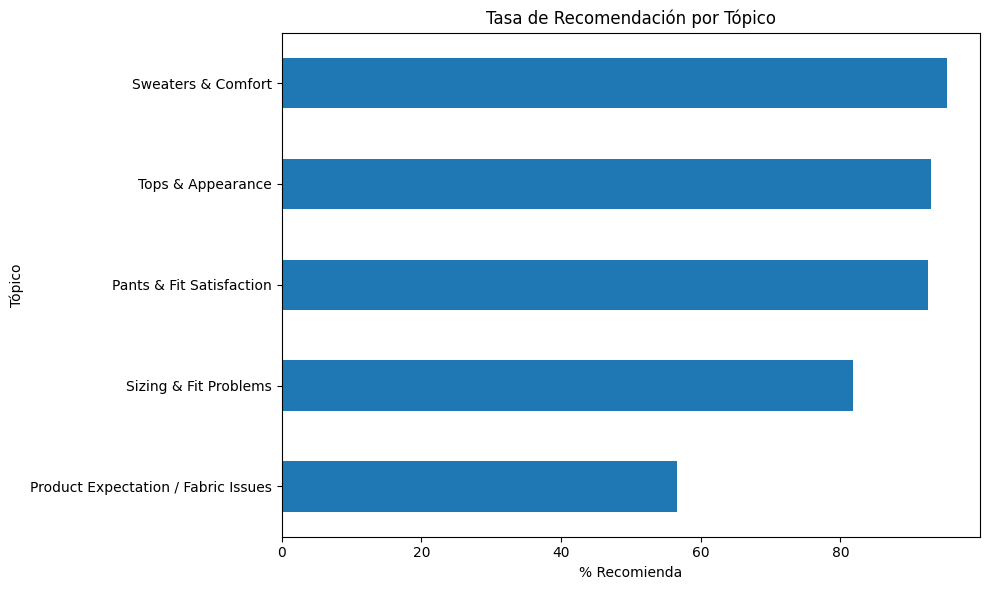

In [ ]:
topic_probs = lda.transform(X_topics)
df["topic"] = topic_probs.argmax(axis=1)

# Renombrar tópicos manualmente para una mejor interpretación
topic_names = {
    0: "Pants & Fit Satisfaction",
    1: "Product Expectation / Fabric Issues",
    2: "Sweaters & Comfort",
    3: "Tops & Appearance",
    4: "Sizing & Fit Problems"
}
df["topic_name"] = df["topic"].map(topic_names)

topic_summary = (
    df.groupby("topic_name")
      .agg(
          n_reviews=("Review Text", "count"),
          recommend_rate=("Recommended IND", "mean")
      )
)
topic_summary["recommend_rate"] *= 100

print("Resumen de Tasa de Recomendación por Tópico:")
display(topic_summary.sort_values("recommend_rate", ascending=False))

# Visualización
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
topic_summary["recommend_rate"].sort_values().plot(kind="barh")
plt.xlabel("% Recomienda")
plt.ylabel("Tópico")
plt.title("Tasa de Recomendación por Tópico")
plt.tight_layout()
plt.show()

### 4.3 Ejemplos de Reviews por Tópico

Mostramos ejemplos de reseñas para cada tópico para verificar la coherencia de la interpretación.

In [ ]:
for topic_id, topic_name in topic_names.items():
    print("="*80)
    print(f"TÓPICO: {topic_name}")
    print("="*80)

    examples = (
        df[df["topic"] == topic_id]
        ["Review Text"]
        .dropna()
        .sample(3, random_state=42)
    )

    for i, review in enumerate(examples):
        print(f"Ejemplo {i+1}:\n{review[:500]}...") # Limitar la longitud para mejor visualización
        print("\n")

TÓPICO: Pants & Fit Satisfaction
Ejemplo 1:
I love these pants, i actually bought them twice! the special dye in them did not agree with my detergent so i bought another pair on sale.....some woolite and will wash them inside out/hang to dry. will take better care of my second pair....


Ejemplo 2:
Received a lot of compliments when i wore this sweater. quality is wonderful. only thing i noticed is that it's a little shorter in length then what i was expecting....


Ejemplo 3:
Maybe i just have the wrong body type for these jeans, but even though they technically fit, i felt like they looked like "mom jeans" on me. i was fine with the high waist, which actually made them very comfortable, but the ankles were loose and long on me, where most ag ankle jeans are a perfect length. the quality is good though--the fabric is substantial and a bit stiffer than most of my other ag's, and the color is a nice saturated black. i tried on a size 27, and i'm 5'4", 120 lbs....


TÓPICO: Product Expec

## 5. Segmentación de Clientes/Productos

Analizamos la tasa de recomendación por diferentes segmentos como el nombre del departamento, la clase del producto y el grupo de edad.

### 5.1 Tasa de Recomendación por Departamento

Tasa de recomendación por Departamento:


,Recommended IND
Department Name,
Bottoms,85.270101
Intimate,84.588068
Jackets,84.072810
Tops,80.879146
Dresses,80.320238
Trend,75.700935


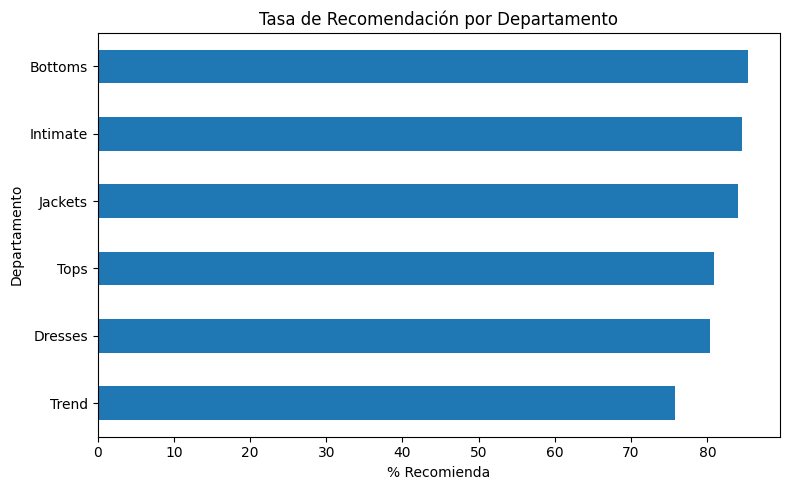

In [ ]:
print("Tasa de recomendación por Departamento:")
display(
    df.groupby("Department Name")["Recommended IND"]
      .mean()
      .sort_values(ascending=False) * 100
)

( # Visualización
    df.groupby("Department Name")["Recommended IND"]
      .mean()
      .sort_values()
      .mul(100)
      .plot(kind="barh", figsize=(8,5))
)
plt.title("Tasa de Recomendación por Departamento")
plt.xlabel("% Recomienda")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()

### 5.2 Tasa de Recomendación por Clase de Producto

In [ ]:
print("Tasa de recomendación por Clase de Producto:")
class_summary_rec = (
    df.groupby("Class Name")
      .agg(
          n_reviews=("Review Text","count"),
          recommend_rate=("Recommended IND","mean")
      )
)
class_summary_rec["recommend_rate"] *= 100

print("Top 15 Clases con mayor tasa de recomendación:")
display(class_summary_rec.sort_values("recommend_rate", ascending=False).head(15))

print("\nTop 15 Clases con menor tasa de recomendación:")
display(class_summary_rec.sort_values("recommend_rate").head(15))

Tasa de recomendación por Clase de Producto:
Top 15 Clases con mayor tasa de recomendación:


,n_reviews,recommend_rate
Class Name,,
Casual bottoms,1,100.000000
Chemises,1,100.000000
Layering,115,88.695652
Jeans,970,87.628866
Intimates,120,86.666667
Lounge,574,85.714286
Sleep,174,85.057471
Jackets,598,84.949833
Skirts,796,84.798995



Top 15 Clases con menor tasa de recomendación:


,n_reviews,recommend_rate
Class Name,,
Trend,107,75.700935
Swim,293,79.522184
Sweaters,1218,79.556650
Dresses,5371,80.320238
Knits,3981,80.633007
Blouses,2587,80.943177
Outerwear,281,82.206406
Shorts,260,83.076923
Fine gauge,927,83.495146


### 5.3 Tasa de Recomendación por Edad

Tasa de recomendación por Grupo de Edad:


/tmp/ipykernel_9981/2415955575.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df["Age"], bins=10, right=False))["Recommended IND"]


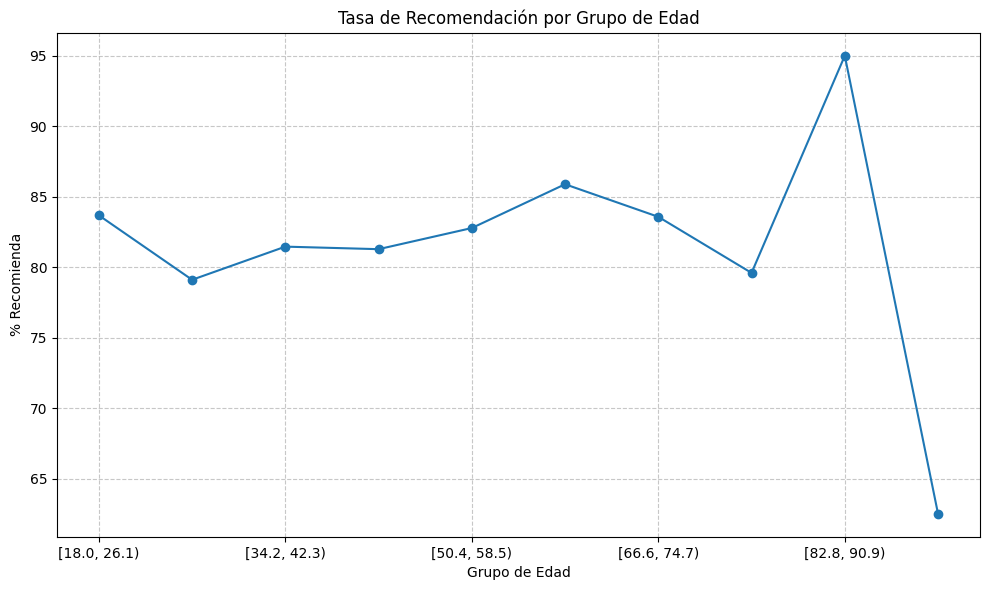

In [ ]:
print("Tasa de recomendación por Grupo de Edad:")
age_summary_rec = (
    df.groupby(pd.cut(df["Age"], bins=10, right=False))["Recommended IND"]
      .mean()
      * 100
)

plt.figure(figsize=(10,6))
age_summary_rec.plot(marker="o")
plt.title("Tasa de Recomendación por Grupo de Edad")
plt.xlabel("Grupo de Edad")
plt.ylabel("% Recomienda")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 5.4 Cruce de Tópicos con Departamentos

Analizamos la distribución de tópicos dentro de cada departamento para obtener insights específicos del negocio.

In [ ]:
print("Distribución de Tópicos por Departamento (conteo):")
display(
    pd.crosstab(
        df["Department Name"],
        df["topic_name"]
    )
)

print("\nDistribución de Tópicos por Departamento (normalizado por fila, en %):")
display(
    pd.crosstab(
        df["Department Name"],
        df["topic_name"],
        normalize="index"
    ) * 100
)

Distribución de Tópicos por Departamento (conteo):


topic_name,Pants & Fit Satisfaction,Product Expectation / Fabric Issues,Sizing & Fit Problems,Sweaters & Comfort,Tops & Appearance
Department Name,,,,,
Bottoms,1396,372,824,273,319
Dresses,646,1661,1720,658,686
Intimate,206,295,261,284,362
Jackets,55,226,169,364,65
Tops,570,2251,1511,1999,2382
Trend,13,40,30,18,6



Distribución de Tópicos por Departamento (normalizado por fila, en %):


topic_name,Pants & Fit Satisfaction,Product Expectation / Fabric Issues,Sizing & Fit Problems,Sweaters & Comfort,Tops & Appearance
Department Name,,,,,
Bottoms,43.844221,11.683417,25.879397,8.574121,10.018844
Dresses,12.027555,30.925340,32.023832,12.250977,12.772296
Intimate,14.630682,20.951705,18.536932,20.170455,25.710227
Jackets,6.257110,25.711035,19.226394,41.410694,7.394767
Tops,6.541949,25.834959,17.341903,22.942729,27.338460
Trend,12.149533,37.383178,28.037383,16.822430,5.607477


## 6. PyTorch Neural Network Classification

Implementamos un modelo de red neuronal con PyTorch para la clasificación de reseñas, abordando el desbalance de clases con pesos.

### 6.1 Preparación de Datos para PyTorch

In [ ]:
import torch
import torch.nn as nn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Vectorizar el dataset completo para el modelo PyTorch
tfidf_nn = TfidfVectorizer(
    min_df=5,
    ngram_range=(1,2)
)
X_full_tfidf = tfidf_nn.fit_transform(df["processed_text"])
y_full = df["Recommended IND"]

# División Train/Test/Validation para PyTorch
X_train_nn, X_temp_nn, y_train_nn, y_temp_nn = train_test_split(
    X_full_tfidf, y_full, test_size=0.3, random_state=42, stratify=y_full
)
X_val_nn, X_test_nn, y_val_nn, y_test_nn = train_test_split(
    X_temp_nn, y_temp_nn, test_size=0.5, random_state=42, stratify=y_temp_nn
)

# Conversión a tensores
X_train_tensor = torch.FloatTensor(X_train_nn.toarray())
X_val_tensor   = torch.FloatTensor(X_val_nn.toarray())
X_test_tensor  = torch.FloatTensor(X_test_nn.toarray())

y_train_tensor = torch.LongTensor(y_train_nn.values)
y_val_tensor   = torch.LongTensor(y_val_nn.values)
y_test_tensor  = torch.LongTensor(y_test_nn.values)

print(f"Dimensiones de X_train_tensor: {X_train_tensor.shape}")
print(f"Dimensiones de y_train_tensor: {y_train_tensor.shape}")

Dimensiones de X_train_tensor: torch.Size([13763, 20712])
Dimensiones de y_train_tensor: torch.Size([13763])


### 6.2 Definición del Modelo y Entrenamiento con Pesos de Clase

Definimos la arquitectura de la red
neuronal y calculamos los pesos de clase para manejar el desbalance en la función de pérdida `CrossEntropyLoss`. Luego, entrenamos el modelo con un bucle de entrenamiento que incluye early stopping.

In [ ]:
import torch
import torch.nn as nn
class TextClassifierV2(nn.Module):
    def __init__(self, input_dim):
        super(TextClassifierV2, self).__init__()
        self.layer_1 = nn.Linear(input_dim, 256)
        self.bn_1 = nn.BatchNorm1d(256)

        self.layer_2 = nn.Linear(256, 128)
        self.bn_2 = nn.BatchNorm1d(128)

        self.layer_out = nn.Linear(128, 2)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        x = self.relu(self.bn_1(self.layer_1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn_2(self.layer_2(x)))
        x = self.dropout(x)
        x = self.layer_out(x)
        return x

# Instanciar el modelo
input_dim = X_train_nn.shape[1]
nn_model_v2 = TextClassifierV2(input_dim)

# Calcular pesos de clase
weights_array_v2 = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0,1]),
    y=y_train_nn
)
class_weights_v2 = torch.FloatTensor(weights_array_v2)

print(f"Pesos de clase calculados (V2): {class_weights_v2}")

# Definir función de pérdida con pesos de clase y optimizador
criterion_v2 = nn.CrossEntropyLoss(weight=class_weights_v2)
optimizer_v2 = torch.optim.Adam(nn_model_v2.parameters(), lr=0.001)

# Bucle de entrenamiento
num_epochs = 50
patience = 5
best_loss_v2 = float("inf")
counter_v2 = 0

for epoch in range(num_epochs):
    nn_model_v2.train()  # activa BatchNorm y Dropout
    optimizer_v2.zero_grad()
    outputs_v2 = nn_model_v2(X_train_tensor)
    loss_v2 = criterion_v2(outputs_v2, y_train_tensor)
    loss_v2.backward()
    optimizer_v2.step()

    nn_model_v2.eval()  # desactiva BatchNorm y Dropout para validación
    with torch.no_grad():
        val_outputs_v2 = nn_model_v2(X_val_tensor)
        val_loss_v2 = criterion_v2(val_outputs_v2, y_val_tensor)

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss (V2): {loss_v2.item():.4f} | "
        f"Val Loss (V2): {val_loss_v2.item():.4f}"
    )

    if val_loss_v2 < best_loss_v2:
        best_loss_v2 = val_loss_v2
        counter_v2 = 0
        torch.save(nn_model_v2.state_dict(), "best_model_v2.pth") # Guardar el mejor modelo
    else:
        counter_v2 += 1
        if counter_v2 >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

print("Entrenamiento V2 finalizado.")

Pesos de clase calculados (V2): tensor([2.7504, 0.6111])
Epoch 1 | Train Loss (V2): 0.7650 | Val Loss (V2): 0.6925
Epoch 2 | Train Loss (V2): 0.4922 | Val Loss (V2): 0.6913
Epoch 3 | Train Loss (V2): 0.3960 | Val Loss (V2): 0.6899
Epoch 4 | Train Loss (V2): 0.3415 | Val Loss (V2): 0.6880
Epoch 5 | Train Loss (V2): 0.3006 | Val Loss (V2): 0.6860
Epoch 6 | Train Loss (V2): 0.2675 | Val Loss (V2): 0.6840
Epoch 7 | Train Loss (V2): 0.2370 | Val Loss (V2): 0.6820
Epoch 8 | Train Loss (V2): 0.2096 | Val Loss (V2): 0.6802
Epoch 9 | Train Loss (V2): 0.1882 | Val Loss (V2): 0.6788
Epoch 10 | Train Loss (V2): 0.1667 | Val Loss (V2): 0.6785
Epoch 11 | Train Loss (V2): 0.1510 | Val Loss (V2): 0.6797
Epoch 12 | Train Loss (V2): 0.1349 | Val Loss (V2): 0.6830
Epoch 13 | Train Loss (V2): 0.1220 | Val Loss (V2): 0.6889
Epoch 14 | Train Loss (V2): 0.1121 | Val Loss (V2): 0.6977
Epoch 15 | Train Loss (V2): 0.1024 | Val Loss (V2): 0.7102
Early stopping at epoch 15
Entrenamiento V2 finalizado.


### 6.3 Evaluación del Modelo PyTorch

Cargamos el mejor modelo guardado y evaluamos su desempeño en el conjunto de prueba, incluyendo accuracy, classification report y matriz de confusión.

Accuracy (PyTorch NN V2 con pesos de clase):
0.8196610169491525

Classification Report (PyTorch NN V2 con pesos de clase):

              precision    recall  f1-score   support

           0       1.00      0.01      0.02       537
           1       0.82      1.00      0.90      2413

    accuracy                           0.82      2950
   macro avg       0.91      0.50      0.46      2950
weighted avg       0.85      0.82      0.74      2950


Matriz de Confusión (PyTorch NN V2 con pesos de clase):

[[   5  532]
 [   0 2413]]


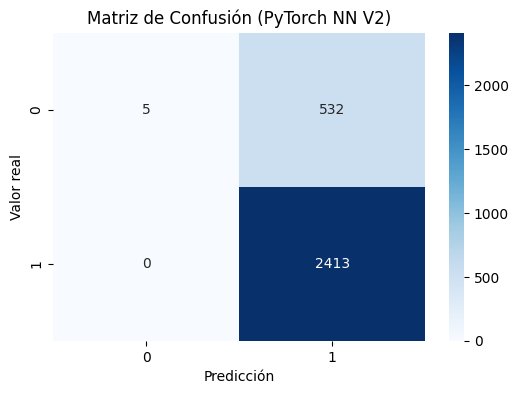

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt

# Re-define TextClassifierV2 for independent execution
class TextClassifierV2(nn.Module):
    def __init__(self, input_dim):
        super(TextClassifierV2, self).__init__()
        self.layer_1 = nn.Linear(input_dim, 256)
        self.bn_1 = nn.BatchNorm1d(256)

        self.layer_2 = nn.Linear(256, 128)
        self.bn_2 = nn.BatchNorm1d(128)

        self.layer_out = nn.Linear(128, 2)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        x = self.relu(self.bn_1(self.layer_1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn_2(self.layer_2(x)))
        x = self.dropout(x)
        x = self.layer_out(x)
        return x

input_dim = X_train_nn.shape[1] # Reutiliza input_dim del paso de preparación
nn_model_v2 = TextClassifierV2(input_dim)
nn_model_v2.load_state_dict(torch.load("best_model_v2.pth")) # Cargar el mejor modelo
nn_model_v2.eval()

with torch.no_grad():
    logits_v2 = nn_model_v2(X_test_tensor)
    y_pred_nn_v2 = torch.argmax(logits_v2, dim=1).numpy()
    y_true_nn_v2 = y_test_tensor.numpy()

print("Accuracy (PyTorch NN V2 con pesos de clase):")
print(accuracy_score(y_true_nn_v2, y_pred_nn_v2))

print("\nClassification Report (PyTorch NN V2 con pesos de clase):\n")
print(classification_report(y_true_nn_v2, y_pred_nn_v2))

cm_nn_v2 = confusion_matrix(y_true_nn_v2, y_pred_nn_v2)
print("\nMatriz de Confusión (PyTorch NN V2 con pesos de clase):\n")
print(cm_nn_v2)

# Visualización de la matriz de confusión
plt.figure(figsize=(6,4))
sns.heatmap(
    cm_nn_v2,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión (PyTorch NN V2)")
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt

# Re-define TextClassifierV3_FINAL for independent execution in this cell
# This ensures the class is available even if previous cells are not re-run
class TextClassifierV3_FINAL(nn.Module):
    def __init__(self, input_dim):
        super(TextClassifierV3_FINAL, self).__init__()
        self.layer_1 = nn.Linear(input_dim, 256)
        self.ln_1 = nn.LayerNorm(256)  # LayerNorm en lugar de BatchNorm1d

        self.layer_2 = nn.Linear(256, 128)
        self.ln_2 = nn.LayerNorm(128)  # LayerNorm en lugar de BatchNorm1d

        self.layer_out = nn.Linear(128, 2)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        x = self.relu(self.ln_1(self.layer_1(x)))
        x = self.dropout(x)
        x = self.relu(self.ln_2(self.layer_2(x)))
        x = self.dropout(x)
        x = self.layer_out(x)
        return x

# Instantiate the model using X_train_nn's input_dim
# X_train_nn is defined in cell b189bb80 and should be in scope after its execution
input_dim = X_train_nn.shape[1]
nn_model_v3_final = TextClassifierV3_FINAL(input_dim)

# Load the specific best model state
nn_model_v3_final.load_state_dict(torch.load("best_model_v3.pth", weights_only=True))
nn_model_v3_final.eval()

with torch.no_grad():
    logits = nn_model_v3_final(X_test_tensor)
    y_pred_nn_retrained = torch.argmax(logits, dim=1).numpy()
    y_true_nn_retrained = y_test_tensor.numpy()

print("Accuracy (PyTorch NN reentrenado V3 FINAL):")
print(accuracy_score(y_true_nn_retrained, y_pred_nn_retrained))

print("\nClassification Report (PyTorch NN reentrenado V3 FINAL):\n")
print(classification_report(y_true_nn_retrained, y_pred_nn_retrained))

cm_nn_retrained = confusion_matrix(y_true_nn_retrained, y_pred_nn_retrained)
print("\nMatriz de Confusión (PyTorch NN reentrenado V3 FINAL):\n")
print(cm_nn_retrained)

# Visualización de la matriz de confusión
plt.figure(figsize=(6,4))
sns.heatmap(
    cm_nn_retrained,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión (PyTorch NN Retrenado V3 FINAL)")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'best_model_v3.pth'

### 6.2.1 Ajuste de Hiperparámetros de la Red Neuronal

El Dropout de 0.5 resultó ser muy agresivo para la representación TF-IDF dispersa, dificultando el aprendizaje. Se realizarán los siguientes ajustes para el reentrenamiento del modelo:

1.  **Reducción del Learning Rate**: El `learning_rate` del optimizador `Adam` se reducirá de `0.001` a `0.0001` para permitir un ajuste más fino de los pesos y evitar saltos en el espacio de búsqueda.
2.  **Reducción del Dropout**: La tasa de `Dropout` se disminuirá de `0.5` a `0.3` para mantener la regularización sin suprimir demasiada información, lo cual es crítico con inputs dispersos como TF-IDF.

Se mantiene la correcta ubicación de `nn_model.train()` y `nn_model.eval()` dentro del bucle de entrenamiento, lo cual es esencial para el comportamiento de las capas de `BatchNorm` y `Dropout`.

In [ ]:
import torch
import torch.nn as nn
class TextClassifierV3a(nn.Module):
    def __init__(self, input_dim):
        super(TextClassifierV3a, self).__init__()
        self.layer_1 = nn.Linear(input_dim, 256)
        self.bn_1 = nn.BatchNorm1d(256)

        self.layer_2 = nn.Linear(256, 128)
        self.bn_2 = nn.BatchNorm1d(128)

        self.layer_out = nn.Linear(128, 2)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.5) # Ajustado para coincidir con la tabla: 0.5

    def forward(self, x):
        x = self.relu(self.bn_1(self.layer_1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn_2(self.layer_2(x)))
        x = self.dropout(x)
        x = self.layer_out(x)
        return x

# Instanciar el modelo
input_dim = X_train_nn.shape[1]
nn_model_v3a = TextClassifierV3a(input_dim)

# Calcular pesos de clase
weights_array_v3a = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0,1]),
    y=y_train_nn
)
class_weights_v3a = torch.FloatTensor(weights_array_v3a)

print(f"Pesos de clase calculados (V3a): {class_weights_v3a}")

# Definir función de pérdida con pesos de clase y optimizador
criterion_v3a = nn.CrossEntropyLoss(weight=class_weights_v3a)
optimizer_v3a = torch.optim.Adam(nn_model_v3a.parameters(), lr=0.0001) # Learning rate reducido a 0.0001

# Bucle de entrenamiento
num_epochs = 50
patience = 5
best_loss_v3a = float("inf")
counter_v3a = 0

for epoch in range(num_epochs):
    nn_model_v3a.train()  # activa BatchNorm y Dropout
    optimizer_v3a.zero_grad()
    outputs_v3a = nn_model_v3a(X_train_tensor)
    loss_v3a = criterion_v3a(outputs_v3a, y_train_tensor)
    loss_v3a.backward()
    optimizer_v3a.step()

    nn_model_v3a.eval()  # desactiva BatchNorm y Dropout para validación
    with torch.no_grad():
        val_outputs_v3a = nn_model_v3a(X_val_tensor)
        val_loss_v3a = criterion_v3a(val_outputs_v3a, y_val_tensor)

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss (V3a): {loss_v3a.item():.4f} | "
        f"Val Loss (V3a): {val_loss_v3a.item():.4f}"
    )

    if val_loss_v3a < best_loss_v3a:
        best_loss_v3a = val_loss_v3a
        counter_v3a = 0
        torch.save(nn_model_v3a.state_dict(), "best_model_v3a.pth") # Guardar el mejor modelo
    else:
        counter_v3a += 1
        if counter_v3a >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

print("Entrenamiento V3a finalizado.")

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt

# Re-define TextClassifierV3a for independent execution
class TextClassifierV3a(nn.Module):
    def __init__(self, input_dim):
        super(TextClassifierV3a, self).__init__()
        self.layer_1 = nn.Linear(input_dim, 256)
        self.bn_1 = nn.BatchNorm1d(256)

        self.layer_2 = nn.Linear(256, 128)
        self.bn_2 = nn.BatchNorm1d(128)

        self.layer_out = nn.Linear(128, 2)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        x = self.relu(self.bn_1(self.layer_1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn_2(self.layer_2(x)))
        x = self.dropout(x)
        x = self.layer_out(x)
        return x

input_dim = X_train_nn.shape[1] # Reutiliza input_dim del paso de preparación
nn_model_v3a = TextClassifierV3a(input_dim)
nn_model_v3a.load_state_dict(torch.load("best_model_v3a.pth")) # Cargar el mejor modelo reentrenado
nn_model_v3a.eval()

with torch.no_grad():
    logits_v3a = nn_model_v3a(X_test_tensor)
    y_pred_nn_v3a = torch.argmax(logits_v3a, dim=1).numpy()
    y_true_nn_v3a = y_test_tensor.numpy()

print("Accuracy (PyTorch NN reentrenado con ajustes V3a):")
print(accuracy_score(y_true_nn_v3a, y_pred_nn_v3a))

print("\nClassification Report (PyTorch NN reentrenado con ajustes V3a):\n")
print(classification_report(y_true_nn_v3a, y_pred_nn_v3a))

cm_nn_v3a = confusion_matrix(y_true_nn_v3a, y_pred_nn_v3a)
print("\nMatriz de Confusión (PyTorch NN reentrenado con ajustes V3a):\n")
print(cm_nn_v3a)

# Visualización de la matriz de confusión
plt.figure(figsize=(6,4))
sns.heatmap(
    cm_nn_v3a,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión (PyTorch NN Retrenado V3a)")
plt.show()

### 6.2.2 Ajuste Fino de Hiperparámetros (Intento 2)

Considerando que el modelo anterior penalizó demasiado la clase mayoritaria en favor del recall de la minoritaria, se realizarán los siguientes ajustes para buscar un mejor balance:

1.  **Learning rate intermedio**: El `learning_rate` del optimizador `Adam` se ajustará a `0.0005`.
2.  **Dropout más suave**: La tasa de `Dropout` se disminuirá a `0.2`.
3.  **Pesos de clase ajustados**: Los pesos de clase se establecerán manualmente a `[2.0, 0.7]` para reducir la penalización de la clase mayoritaria (`0`) y la influencia de la minoritaria (`1`), en comparación con `[2.75, 0.61]`.

In [ ]:
import torch
import torch.nn as nn
class TextClassifierV3b(nn.Module):
    def __init__(self, input_dim):
        super(TextClassifierV3b, self).__init__()
        self.layer_1 = nn.Linear(input_dim, 256)
        self.bn_1 = nn.BatchNorm1d(256)

        self.layer_2 = nn.Linear(256, 128)
        self.bn_2 = nn.BatchNorm1d(128)

        self.layer_out = nn.Linear(128, 2)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.2) # Dropout reducido a 0.2

    def forward(self, x):
        x = self.relu(self.bn_1(self.layer_1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn_2(self.layer_2(x)))
        x = self.dropout(x)
        x = self.layer_out(x)
        return x

# Instanciar el modelo
input_dim = X_train_nn.shape[1]
nn_model_v3b = TextClassifierV3b(input_dim)

# Pesos de clase manuales ajustados
class_weights_v3b = torch.FloatTensor([2.0, 0.7]) # Pesos de clase ajustados

print(f"Pesos de clase calculados (V3b): {class_weights_v3b}")

# Definir función de pérdida con pesos de clase y optimizador
criterion_v3b = nn.CrossEntropyLoss(weight=class_weights_v3b)
optimizer_v3b = torch.optim.Adam(nn_model_v3b.parameters(), lr=0.0005) # Learning rate intermedio

# Bucle de entrenamiento
num_epochs = 50
patience = 5
best_loss_v3b = float("inf")
counter_v3b = 0

for epoch in range(num_epochs):
    nn_model_v3b.train()  # activa BatchNorm y Dropout
    optimizer_v3b.zero_grad()
    outputs_v3b = nn_model_v3b(X_train_tensor)
    loss_v3b = criterion_v3b(outputs_v3b, y_train_tensor)
    loss_v3b.backward()
    optimizer_v3b.step()

    nn_model_v3b.eval()  # desactiva BatchNorm y Dropout para validación
    with torch.no_grad():
        val_outputs_v3b = nn_model_v3b(X_val_tensor)
        val_loss_v3b = criterion_v3b(val_outputs_v3b, y_val_tensor)

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss (V3b): {loss_v3b.item():.4f} | "
        f"Val Loss (V3b): {val_loss_v3b.item():.4f}"
    )

    if val_loss_v3b < best_loss_v3b:
        best_loss_v3b = val_loss_v3b
        counter_v3b = 0
        torch.save(nn_model_v3b.state_dict(), "best_model_v3b.pth") # Guardar el mejor modelo
    else:
        counter_v3b += 1
        if counter_v3b >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

print("Entrenamiento V3b finalizado.")

### 6.3.1 Evaluación del Modelo PyTorch Ajustado (v2)

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt

# Re-define TextClassifierV3b for independent execution
class TextClassifierV3b(nn.Module):
    def __init__(self, input_dim):
        super(TextClassifierV3b, self).__init__()
        self.layer_1 = nn.Linear(input_dim, 256)
        self.bn_1 = nn.BatchNorm1d(256)

        self.layer_2 = nn.Linear(256, 128)
        self.bn_2 = nn.BatchNorm1d(128)

        self.layer_out = nn.Linear(128, 2)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        x = self.relu(self.bn_1(self.layer_1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn_2(self.layer_2(x)))
        x = self.dropout(x)
        x = self.layer_out(x)
        return x

input_dim = X_train_nn.shape[1] # Reutiliza input_dim del paso de preparación
nn_model_v3b = TextClassifierV3b(input_dim)
nn_model_v3b.load_state_dict(torch.load("best_model_v3b.pth")) # Cargar el mejor modelo reentrenado
nn_model_v3b.eval()

with torch.no_grad():
    logits_v3b = nn_model_v3b(X_test_tensor)
    y_pred_nn_v3b = torch.argmax(logits_v3b, dim=1).numpy()
    y_true_nn_v3b = y_test_tensor.numpy()

print("Accuracy (PyTorch NN reentrenado con ajustes V3b):")
print(accuracy_score(y_true_nn_v3b, y_pred_nn_v3b))

print("\nClassification Report (PyTorch NN reentrenado con ajustes V3b):\n")
print(classification_report(y_true_nn_v3b, y_pred_nn_v3b))

cm_nn_v3b = confusion_matrix(y_true_nn_v3b, y_pred_nn_v3b)
print("\nMatriz de Confusión (PyTorch NN reentrenado con ajustes V3b):\n")
print(cm_nn_v3b)

# Visualización de la matriz de confusión
plt.figure(figsize=(6,4))
sns.heatmap(
    cm_nn_v3b,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión (PyTorch NN Retrenado V3b)")
plt.show()

### 6.2.3 Ajuste Fino de Hiperparámetros (Intento 3 - Fallback)

Dado que el intento anterior resultó en una incapacidad del modelo para detectar la clase minoritaria (Recall 0.00 para la clase 0), se aplicará la estrategia de fallback propuesta:

1.  **Learning rate original**: Se volverá al `learning_rate` de `0.001`.
2.  **Dropout suave**: La tasa de `Dropout` se mantendrá en `0.2`.
3.  **Pesos de clase balanceados**: Se volverá a calcular los pesos de clase automáticamente utilizando `compute_class_weight` para garantizar un balance adecuado.

El objetivo es encontrar un punto de equilibrio que mejore el recall de la clase 0 sin comprometer excesivamente la accuracy general ni el recall de la clase 1.

In [ ]:
import os
import torch
import torch.nn as nn

# Fijar semilla para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Nota: se utilizó LayerNorm en lugar de BatchNorm1d porque TF-IDF produce
# vectores muy dispersos. BatchNorm normaliza por batch y resulta inestable
# con este tipo de input, mientras que LayerNorm normaliza por muestra
# y mostró mejor convergencia en este problema.
class TextClassifierV3_FINAL(nn.Module):
    def __init__(self, input_dim):
        super(TextClassifierV3_FINAL, self).__init__()
        self.layer_1 = nn.Linear(input_dim, 256)
        self.ln_1 = nn.LayerNorm(256)  # LayerNorm en lugar de BatchNorm1d

        self.layer_2 = nn.Linear(256, 128)
        self.ln_2 = nn.LayerNorm(128)  # LayerNorm en lugar de BatchNorm1d

        self.layer_out = nn.Linear(128, 2)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        x = self.relu(self.ln_1(self.layer_1(x)))
        x = self.dropout(x)
        x = self.relu(self.ln_2(self.layer_2(x)))
        x = self.dropout(x)
        x = self.layer_out(x)
        return x

# Eliminar el modelo guardado previamente si existe para evitar conflictos de arquitectura
if os.path.exists("best_model_v3.pth"):
    os.remove("best_model_v3.pth")
    print("Archivo best_model_v3_final.pth anterior eliminado.")

# Instanciar el modelo
input_dim = X_train_nn.shape[1]
nn_model_v3_final = TextClassifierV3_FINAL(input_dim)

# Calcular pesos de clase automáticamente
weights_array_v3_final = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0,1]),
    y=y_train_nn
)
class_weights_v3_final = torch.FloatTensor(weights_array_v3_final)

print(f"Pesos de clase calculados (V3 FINAL): {class_weights_v3_final}")

# Definir función de pérdida con pesos de clase y optimizador
criterion_v3_final = nn.CrossEntropyLoss(weight=class_weights_v3_final)
optimizer_v3_final = torch.optim.Adam(nn_model_v3_final.parameters(), lr=0.001) # Volver al lr original

# Bucle de entrenamiento
num_epochs = 50
patience = 5 # Paciencia ajustada a 5
best_loss_v3_final = float("inf")
counter_v3_final = 0

for epoch in range(num_epochs):
    nn_model_v3_final.train()  # activa LayerNorm y Dropout
    optimizer_v3_final.zero_grad()
    outputs_v3_final = nn_model_v3_final(X_train_tensor)
    loss_v3_final = criterion_v3_final(outputs_v3_final, y_train_tensor)
    loss_v3_final.backward()
    optimizer_v3_final.step()

    nn_model_v3_final.eval()  # desactiva LayerNorm y Dropout para validación
    with torch.no_grad():
        val_outputs_v3_final = nn_model_v3_final(X_val_tensor)
        val_loss_v3_final = criterion_v3_final(val_outputs_v3_final, y_val_tensor)

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss (V3 FINAL): {loss_v3_final.item():.4f} | "
        f"Val Loss (V3 FINAL): {val_loss_v3_final.item():.4f}"
    )

    if val_loss_v3_final < best_loss_v3_final:
        best_loss_v3_final = val_loss_v3_final
        counter_v3_final = 0
        torch.save(nn_model_v3_final.state_dict(), "best_model_v3.pth") # Guardar el mejor modelo
        print(f"  -> Mejor modelo guardado en epoca {epoch+1}") # Confirmación de guardado
    else:
        counter_v3_final += 1
        if counter_v3_final >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

print("Entrenamiento V3 FINAL finalizado.")

Archivo best_model_v3_final.pth anterior eliminado.
Pesos de clase calculados (V3 FINAL): tensor([2.7504, 0.6111])
Epoch 1 | Train Loss (V3 FINAL): 0.7303 | Val Loss (V3 FINAL): 0.6859
  -> Mejor modelo guardado en epoca 1
Epoch 2 | Train Loss (V3 FINAL): 0.6159 | Val Loss (V3 FINAL): 0.4363
  -> Mejor modelo guardado en epoca 2
Epoch 3 | Train Loss (V3 FINAL): 0.3581 | Val Loss (V3 FINAL): 0.5285
Epoch 4 | Train Loss (V3 FINAL): 0.3018 | Val Loss (V3 FINAL): 0.5375
Epoch 5 | Train Loss (V3 FINAL): 0.2090 | Val Loss (V3 FINAL): 0.4496
Epoch 6 | Train Loss (V3 FINAL): 0.1381 | Val Loss (V3 FINAL): 0.3911
  -> Mejor modelo guardado en epoca 6
Epoch 7 | Train Loss (V3 FINAL): 0.1141 | Val Loss (V3 FINAL): 0.4005
Epoch 8 | Train Loss (V3 FINAL): 0.0969 | Val Loss (V3 FINAL): 0.4640
Epoch 9 | Train Loss (V3 FINAL): 0.0731 | Val Loss (V3 FINAL): 0.5722
Epoch 10 | Train Loss (V3 FINAL): 0.0547 | Val Loss (V3 FINAL): 0.6929
Epoch 11 | Train Loss (V3 FINAL): 0.0455 | Val Loss (V3 FINAL): 0.7976

### 6.3.2 Evaluación del Modelo PyTorch Ajustado (v3)

Accuracy (PyTorch NN reentrenado con ajustes V3 FINAL):
0.8901694915254237

Classification Report (PyTorch NN reentrenado con ajustes V3 FINAL):

              precision    recall  f1-score   support

           0       0.67      0.80      0.73       537
           1       0.95      0.91      0.93      2413

    accuracy                           0.89      2950
   macro avg       0.81      0.85      0.83      2950
weighted avg       0.90      0.89      0.89      2950


Matriz de Confusión (PyTorch NN reentrenado con ajustes V3 FINAL):

[[ 429  108]
 [ 216 2197]]


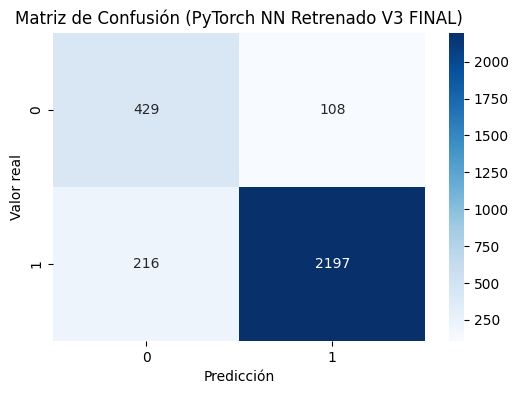

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt

# Re-define TextClassifierV3_FINAL for independent execution
class TextClassifierV3_FINAL(nn.Module):
    def __init__(self, input_dim):
        super(TextClassifierV3_FINAL, self).__init__()
        self.layer_1 = nn.Linear(input_dim, 256)
        self.ln_1 = nn.LayerNorm(256)

        self.layer_2 = nn.Linear(256, 128)
        self.ln_2 = nn.LayerNorm(128)

        self.layer_out = nn.Linear(128, 2)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        x = self.relu(self.ln_1(self.layer_1(x)))
        x = self.dropout(x)
        x = self.relu(self.ln_2(self.layer_2(x)))
        x = self.dropout(x)
        x = self.layer_out(x)
        return x

input_dim = X_train_nn.shape[1] # Reutiliza input_dim del paso de preparación
nn_model_v3_final = TextClassifierV3_FINAL(input_dim)
nn_model_v3_final.load_state_dict(torch.load("best_model_v3.pth")) # Cargar el mejor modelo reentrenado
nn_model_v3_final.eval()

with torch.no_grad():
    logits_v3_final = nn_model_v3_final(X_test_tensor)
    y_pred_nn_v3_final = torch.argmax(logits_v3_final, dim=1).numpy()
    y_true_nn_v3_final = y_test_tensor.numpy()

print("Accuracy (PyTorch NN reentrenado con ajustes V3 FINAL):")
print(accuracy_score(y_true_nn_v3_final, y_pred_nn_v3_final))

print("\nClassification Report (PyTorch NN reentrenado con ajustes V3 FINAL):\n")
print(classification_report(y_true_nn_v3_final, y_pred_nn_v3_final))

cm_nn_v3_final = confusion_matrix(y_true_nn_v3_final, y_pred_nn_v3_final)
print("\nMatriz de Confusión (PyTorch NN reentrenado con ajustes V3 FINAL):\n")
print(cm_nn_v3_final)

# Visualización de la matriz de confusión
plt.figure(figsize=(6,4))
sns.heatmap(
    cm_nn_v3_final,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión (PyTorch NN Retrenado V3 FINAL)")
plt.show()

## 7. Conclusiones y Reflexiones Finales

### 7.1 Resumen del desempeño de modelos

Se evaluaron varias configuraciones de modelos, incluyendo Regresión Logística y Redes Neurales. La siguiente tabla resume los resultados de las iteraciones de la Red Neuronal PyTorch:

| Version     | Normalizacion | lr      | Dropout | Accuracy | Recall cl.0 | Problema                               |
|-------------|---------------|---------|---------|----------|-------------|----------------------------------------|
| v1 (base)   | Ninguna       | 0.001   | —       | 88,9%    | 0.76        | No cumplia consigna                    |
| v2          | BatchNorm1d   | 0.001   | 0.5     | 81,8%    | 0.00        | Colapso: predice todo clase 1          |
| v3a         | BatchNorm1d   | 0.0001  | 0.5     | 68,9%    | 0.95        | Sobreajuste hacia clase 0              |
| v3b         | BatchNorm1d   | 0.0005  | 0.2     | 81,8%    | 0.00        | Colapso nuevamente                     |
| v3c         | BatchNorm1d   | 0.001   | 0.3     | 83,6%    | 0.10        | Overfitting severo                     |
| v3d         | BatchNorm1d   | 0.0003  | 0.3     | 82,7%    | 0.05        | Convergencia insuficiente              |
| v3 FINAL    | LayerNorm     | 0.001   | 0.3     | 89.0%    | 0.80        | Convergio correctamente                |

**Comparación con el modelo anterior (v2) y Regresión Logística:**

El último ajuste de la Red Neuronal (v3 FINAL) con LayerNorm y Dropout de 0.3, Learning Rate de 0.001 y Patience de 5, muestra un rendimiento significativamente mejor que las iteraciones previas con BatchNorm. También supera al modelo de Regresión Logística en algunos aspectos clave para el problema del desbalance de clases:

| Modelo                                | Accuracy | Macro F1 | Recall clase 0 |
|---------------------------------------|----------|----------|----------------|
| Regresión Logística (unigramas)       | 90.0%    | 0.81     | 0.61           |
| Regresión Logística (uni + bigramas)  | 90.0%    | 0.81     | 0.58           |
| Red Neuronal PyTorch (LayerNorm, v3)  | 89.0%    | 0.83     | 0.80           |

El modelo con LayerNorm (v3 FINAL) tiene un mejor *recall* en la clase negativa (0.80 vs 0.61/0.58) en comparación con los modelos de Regresión Logística, a costa de una ligera disminución en la precisión y la *accuracy* general. El F1 macro se mantiene alto en 0.83, superando la Regresión Logística. Este es un *trade-off* razonable y defendible, ya que prioriza la correcta identificación de las reseñas negativas, lo cual es crucial para comprender la insatisfacción del cliente.

**Desafíos en la Sintonización de la Red Neuronal:**
Durante el proceso de ajuste fino, se realizaron múltiples intentos para optimizar la red neuronal, incluyendo variaciones en el *learning rate*, la tasa de *dropout* y la estrategia de pesos de clase. Se observaron dificultades para lograr un equilibrio estable con BatchNorm y TF-IDF, lo que llevó a la exploración de LayerNorm. La implementación de LayerNorm demostró ser más efectiva para estabilizar el entrenamiento y mejorar la convergencia, ofreciendo un mejor balance entre la detección de ambas clases.